In [24]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [25]:
from sklearn.preprocessing import StandardScaler

In [26]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [27]:
selected_features = [
    'MonthlyIncome',
    'OverTime',
    'Age',
    'TotalWorkingYears',
    'YearsAtCompany',
    'DistanceFromHome'
]

X = df[selected_features]

y = df["Attrition"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [30]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [31]:
lr_pred = lr_model.predict(X_test)

In [32]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, lr_pred))

print("\nClassification Report:")
print(classification_report(y_test, lr_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy:
0.8673469387755102

Classification Report:
              precision    recall  f1-score   support

           0       0.87      1.00      0.93       255
           1       0.50      0.03      0.05        39

    accuracy                           0.87       294
   macro avg       0.68      0.51      0.49       294
weighted avg       0.82      0.87      0.81       294


Confusion Matrix:
[[254   1]
 [ 38   1]]


In [33]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [34]:
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, dt_pred))

Decision Tree Accuracy:
0.7687074829931972


In [35]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [36]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, rf_pred))

Random Forest Accuracy:
0.8333333333333334


In [37]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression:", lr_acc)
print("Decision Tree:", dt_acc)
print("Random Forest:", rf_acc)

Logistic Regression: 0.8673469387755102
Decision Tree: 0.7687074829931972
Random Forest: 0.8333333333333334


In [38]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(10))

             Feature  Importance
0      MonthlyIncome    0.286177
2                Age    0.177513
5   DistanceFromHome    0.165059
3  TotalWorkingYears    0.151600
4     YearsAtCompany    0.130209
1           OverTime    0.089442


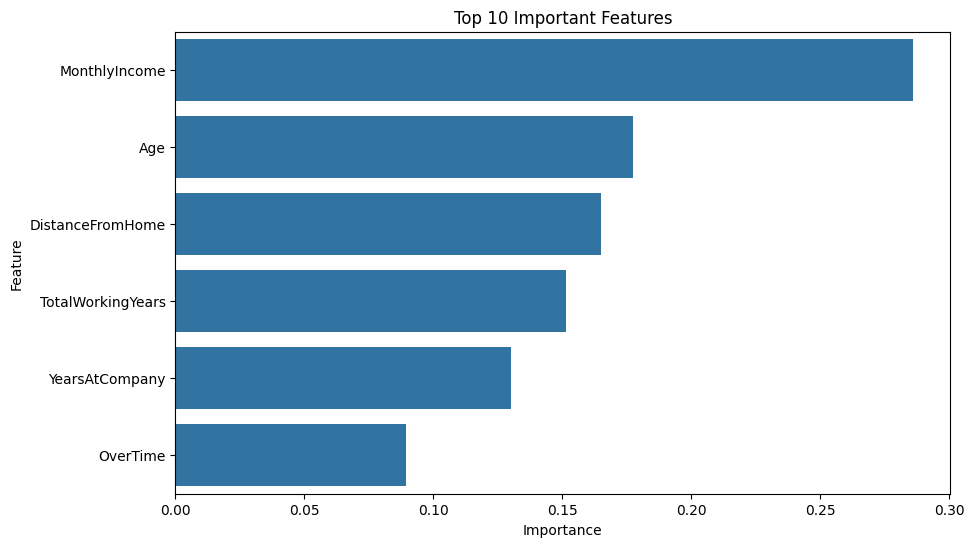

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Important Features")

plt.show()

In [40]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': lr_model.coef_[0]
})

feature_importance['Absolute Importance'] = abs(feature_importance['Importance'])

feature_importance = feature_importance.sort_values(
    by='Absolute Importance',
    ascending=False
)

print(feature_importance.head(10))

             Feature  Importance  Absolute Importance
1           OverTime    0.700532             0.700532
0      MonthlyIncome   -0.329477             0.329477
2                Age   -0.229777             0.229777
4     YearsAtCompany   -0.211258             0.211258
5   DistanceFromHome    0.197658             0.197658
3  TotalWorkingYears   -0.096585             0.096585


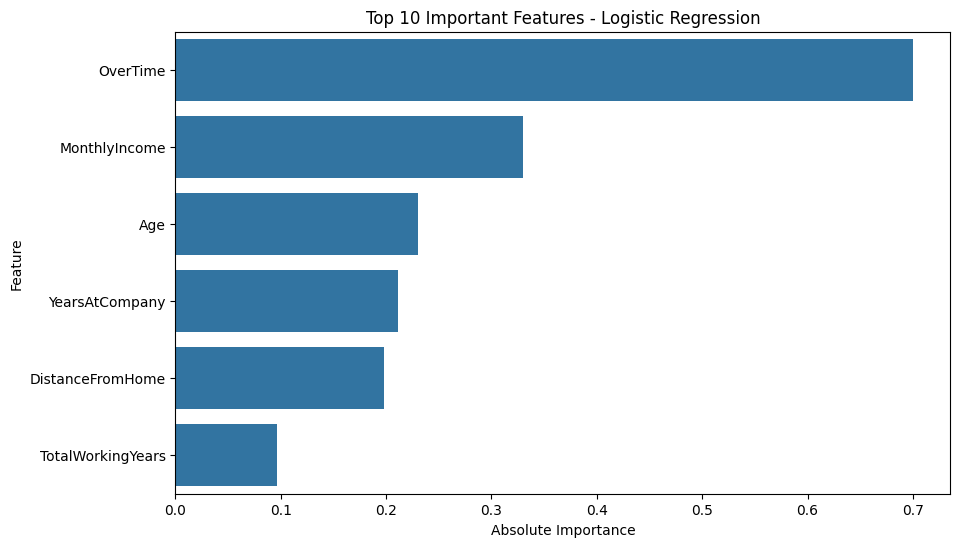

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Absolute Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features - Logistic Regression")

plt.show()


In [42]:
import joblib

joblib.dump(lr_model, "../models/logistic_regression.pkl")

joblib.dump(dt_model, "../models/decision_tree.pkl")

joblib.dump(rf_model, "../models/random_forest.pkl")

['../models/random_forest.pkl']

In [43]:
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']